<a href="https://colab.research.google.com/github/kanepeters/lis4693/blob/main/lab-7/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries for sentiment analysis.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

Load the assigned dataset from Lab 4 (AG News Dataset).

In [45]:
import requests
import io

url = "https://raw.githubusercontent.com/kanepeters/lis4693/refs/heads/main/lab-4/train.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text))
print(df.head())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


Create new indices for each record in the data frame.

In [46]:
df['ID'] = range(1, len(df) + 1)
# Reorder the ID column as the first column
df = df[['ID'] + [col for col in df.columns if col != 'ID']]
print(df.head())

   ID  Class Index                                              Title  \
0   1            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1   2            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2   3            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3   4            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4   5            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


Create a subset of the data frame. Use the "Description" field as the "text" field for sentiment analysis.

In [47]:
df_subset = df[['ID', 'Description']].copy()
print(df_subset.head())

   ID                                        Description
0   1  Reuters - Short-sellers, Wall Street's dwindli...
1   2  Reuters - Private investment firm Carlyle Grou...
2   3  Reuters - Soaring crude prices plus worries\ab...
3   4  Reuters - Authorities have halted oil export\f...
4   5  AFP - Tearaway world oil prices, toppling reco...


Remove all non-alphanumeric characters from the "Description" field.

In [48]:
df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", " ", regex=True)
# Convert instances of multiple consecutive whitespaces to a single whitespace
df_subset['Description'] = df_subset['Description'].str.replace("\s+", " ", regex=True)
print(df_subset.head())

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4135/653017383.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_subset['Description'] = df_subset['Description'].str.replace("\s+", " ", regex=True)


   ID                                        Description
0   1  Reuters Short sellers Wall Street s dwindling ...
1   2  Reuters Private investment firm Carlyle Group ...
2   3  Reuters Soaring crude prices plus worries abou...
3   4  Reuters Authorities have halted oil export flo...
4   5  AFP Tearaway world oil prices toppling records...


Convert all letters to lowercase.

In [49]:
df_subset['Description'] = df_subset['Description'].str.casefold()
print(df_subset.head(10))

   ID                                        Description
0   1  reuters short sellers wall street s dwindling ...
1   2  reuters private investment firm carlyle group ...
2   3  reuters soaring crude prices plus worries abou...
3   4  reuters authorities have halted oil export flo...
4   5  afp tearaway world oil prices toppling records...
5   6  reuters stocks ended slightly higher on friday...
6   7  ap assets of the nation s retail money market ...
7   8  usatoday com retail sales bounced back a bit i...
8   9  forbes com after earning a ph d in sociology d...
9  10   new york reuters short sellers wall street s ...


Create a dataframe to stage the output of the SentimentIntensityAnalyzer.polarity_scores method. Initialize with dummy data.

In [50]:
df1 = pd.DataFrame()
df1['ObjectId'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

Instantiate the SentimentIntensityAnalyzer.

Iterate over the input dataframe with the polarity_scores method.

Delete the dummy row from the output dataframe.

Remove any duplicate rows.

Filter the output dataframe; only keep rows with the "compound" sentiment type.


In [51]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'ID': row['ID'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    ID sentiment_type  sentiment_score
3    1       compound          -0.0772
7    2       compound           0.4243
11   3       compound          -0.7579
15   4       compound           0.2500
19   5       compound          -0.6705
23   6       compound           0.5719
27   7       compound           0.1779
31   8       compound           0.6597
35   9       compound          -0.0516
39  10       compound          -0.0772


Merge the output dataframe with the input dataframe; use the "ID" column to merge the original dataset with the sentiment scores.

In [52]:

df_output = pd.merge(df, t_df_cleaned, on='ID', how='inner')
print(df_output.head(10))

   ID  Class Index                                              Title  \
0   1            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1   2            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2   3            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3   4            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4   5            3  Oil prices soar to all-time record, posing new...   
5   6            3        Stocks End Up, But Near Year Lows (Reuters)   
6   7            3               Money Funds Fell in Latest Week (AP)   
7   8            3  Fed minutes show dissent over inflation (USATO...   
8   9            3                            Safety Net (Forbes.com)   
9  10            3            Wall St. Bears Claw Back Into the Black   

                                         Description sentiment_type  \
0  Reuters - Short-sellers, Wall Street's dwindli...       compound   
1  Reuters - Private investment firm Carlyle Grou...  

Visualization: Generate summary statistics for sentiment_score in the output dataframe.

In [53]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,120000.000000
mean,0.048000
std,0.504499
min,-0.991400
25%,-0.340000
50%,0.000000
75%,0.458800
max,0.992800


The minimum value is -0.99, indicating the polarity of the most negative description was highly negative (very close to -1).

The maximum value is +0.99, indicate the polarity of the most negative description was highly positive (very close to +1).

The mean value is +0.04, indicating the average polarity across all descriptions was in positive territory.

Visualize sentiment results with respect to class index.

Per Kaggle, the class index indicates the category of the news article: 1-World, 2-Sports, 3-Business, 4-Sci/Tech.



In [72]:
# Use the Altair library to create one visualization
import altair as alt

# Generate mean sentiment score with respect to the class indices.
# (1-World, 2-Sports, 3-Business, 4-Sci/Tech)
alt.Chart(df_output).mark_bar().encode(
    x=alt.X('Class Index:N', title='Class Index'),
    y=alt.Y('mean(sentiment_score):Q', title='Mean Sentiment Score')
).properties(
    width=400,
    height=400,
    title='Mean Sentiment Score by Class Index'
).interactive()

alt.Chart(...)

Comparatively, the mean sentiment score for news items other than those dealing with "World" news is positive; by contrast, world news has a negative mean sentiment score. This suggests that world news items tend to be negative on average.

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3'), Text(3, 0, '4')])

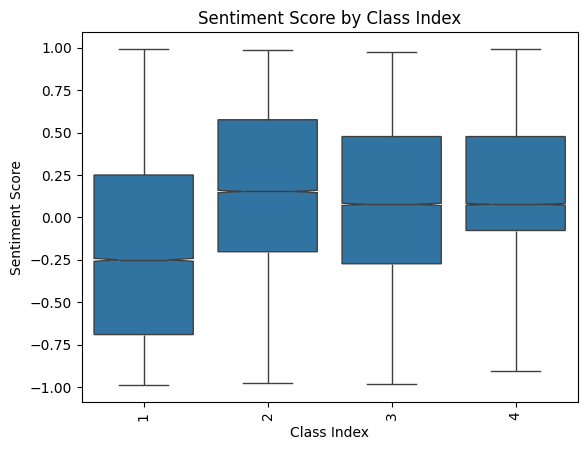

In [71]:
# Use the Seaborn library to generate one visualization
import seaborn as sns

# Create seaborn boxplots by class index.
sns.boxplot(x='Class Index', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Class Index')
# Axis labels
plt.xlabel('Class Index')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=90)

The overall ranges for all the class indices are similar; each type of news item has similar potential to have both highly negative or positive descriptions. The interquartile range for "World" news is the largest among the class indices. Similar to the results from the mean sentiment score visualization, this visualization signals that World news tends to be negative.

Reflection:

Visualizing the sentiment scores gave useful, interpretable results about the dataset.

With respect to challenges, the original dataset had to have a column of indices generated to be usable with SentimentIntensityAnalyzer.

Incorporating this type of analysis into professional or research work will make it easier to get a sense of the sentiments contained in a large amount of information like that contained in the dataset (about 120,000 records). As demonstrated through the visualization, I can even get a sense of the type of sentiment contained within different genres of news.